In [12]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [13]:
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv('results/combined_run_summary.csv')

In [15]:
df.head()

,dataset,namespace,index_name,user_namespace,embed_model,top_k,persona,combine_strategy,rerank_strategy,update_strategy,alpha_mode,alpha_value,alpha_start,alpha_step,alpha_floor,final_alpha,case_count,mean_baseline_score,mean_post_score,mean_delta,wins,mean_baseline_rank,mean_post_rank,expected_retrieval_rate
0,civil,zai,541,users,llama-text-embed-v2,5,civil,linear-comb,cross-encoder,moving-average,sliding,NaN,0.99,0.02,0.7,0.79,10,8.381758,8.619672,0.237914,5,2.3,2.3,0.8
1,civil,zai,541,users,llama-text-embed-v2,5,civil,linear-comb,cross-encoder,moving-average,static,0.50,NaN,NaN,NaN,0.50,10,8.381758,9.834133,1.452375,8,2.3,1.9,0.9
2,civil,zai,541,users,llama-text-embed-v2,5,civil,linear-comb,cross-encoder,moving-average,static,0.80,NaN,NaN,NaN,0.80,10,8.381758,8.576604,0.194846,4,2.3,2.3,0.8
3,civil,zai,541,users,llama-text-embed-v2,5,civil,linear-comb,cross-encoder,moving-average,static,0.95,NaN,NaN,NaN,0.95,10,8.381758,8.431758,0.050000,1,2.3,2.3,0.8
4,civil,zai,541,users,llama-text-embed-v2,5,civil,linear-comb,cross-encoder,none,sliding,NaN,0.99,0.02,0.7,0.99,10,8.381758,8.381758,0.000000,0,2.3,2.3,0.8


In [16]:
cols = ["mean_baseline_score", "mean_post_score", "mean_delta"]
df[cols] = df[cols] / 11.948459118879

In [6]:
df.head()

,dataset,namespace,index_name,user_namespace,embed_model,top_k,persona,combine_strategy,rerank_strategy,update_strategy,alpha_mode,alpha_value,alpha_start,alpha_step,alpha_floor,final_alpha,case_count,mean_baseline_score,mean_post_score,mean_delta,wins,mean_baseline_rank,mean_post_rank,expected_retrieval_rate
0,civil,zai,541,users,llama-text-embed-v2,5,civil,linear-comb,cross-encoder,moving-average,sliding,NaN,0.99,0.02,0.7,0.79,10,8.381758,8.619672,0.237914,5,2.3,2.3,0.8
1,civil,zai,541,users,llama-text-embed-v2,5,civil,linear-comb,cross-encoder,moving-average,static,0.50,NaN,NaN,NaN,0.50,10,8.381758,9.834133,1.452375,8,2.3,1.9,0.9
2,civil,zai,541,users,llama-text-embed-v2,5,civil,linear-comb,cross-encoder,moving-average,static,0.80,NaN,NaN,NaN,0.80,10,8.381758,8.576604,0.194846,4,2.3,2.3,0.8
3,civil,zai,541,users,llama-text-embed-v2,5,civil,linear-comb,cross-encoder,moving-average,static,0.95,NaN,NaN,NaN,0.95,10,8.381758,8.431758,0.050000,1,2.3,2.3,0.8
4,civil,zai,541,users,llama-text-embed-v2,5,civil,linear-comb,cross-encoder,none,sliding,NaN,0.99,0.02,0.7,0.99,10,8.381758,8.381758,0.000000,0,2.3,2.3,0.8


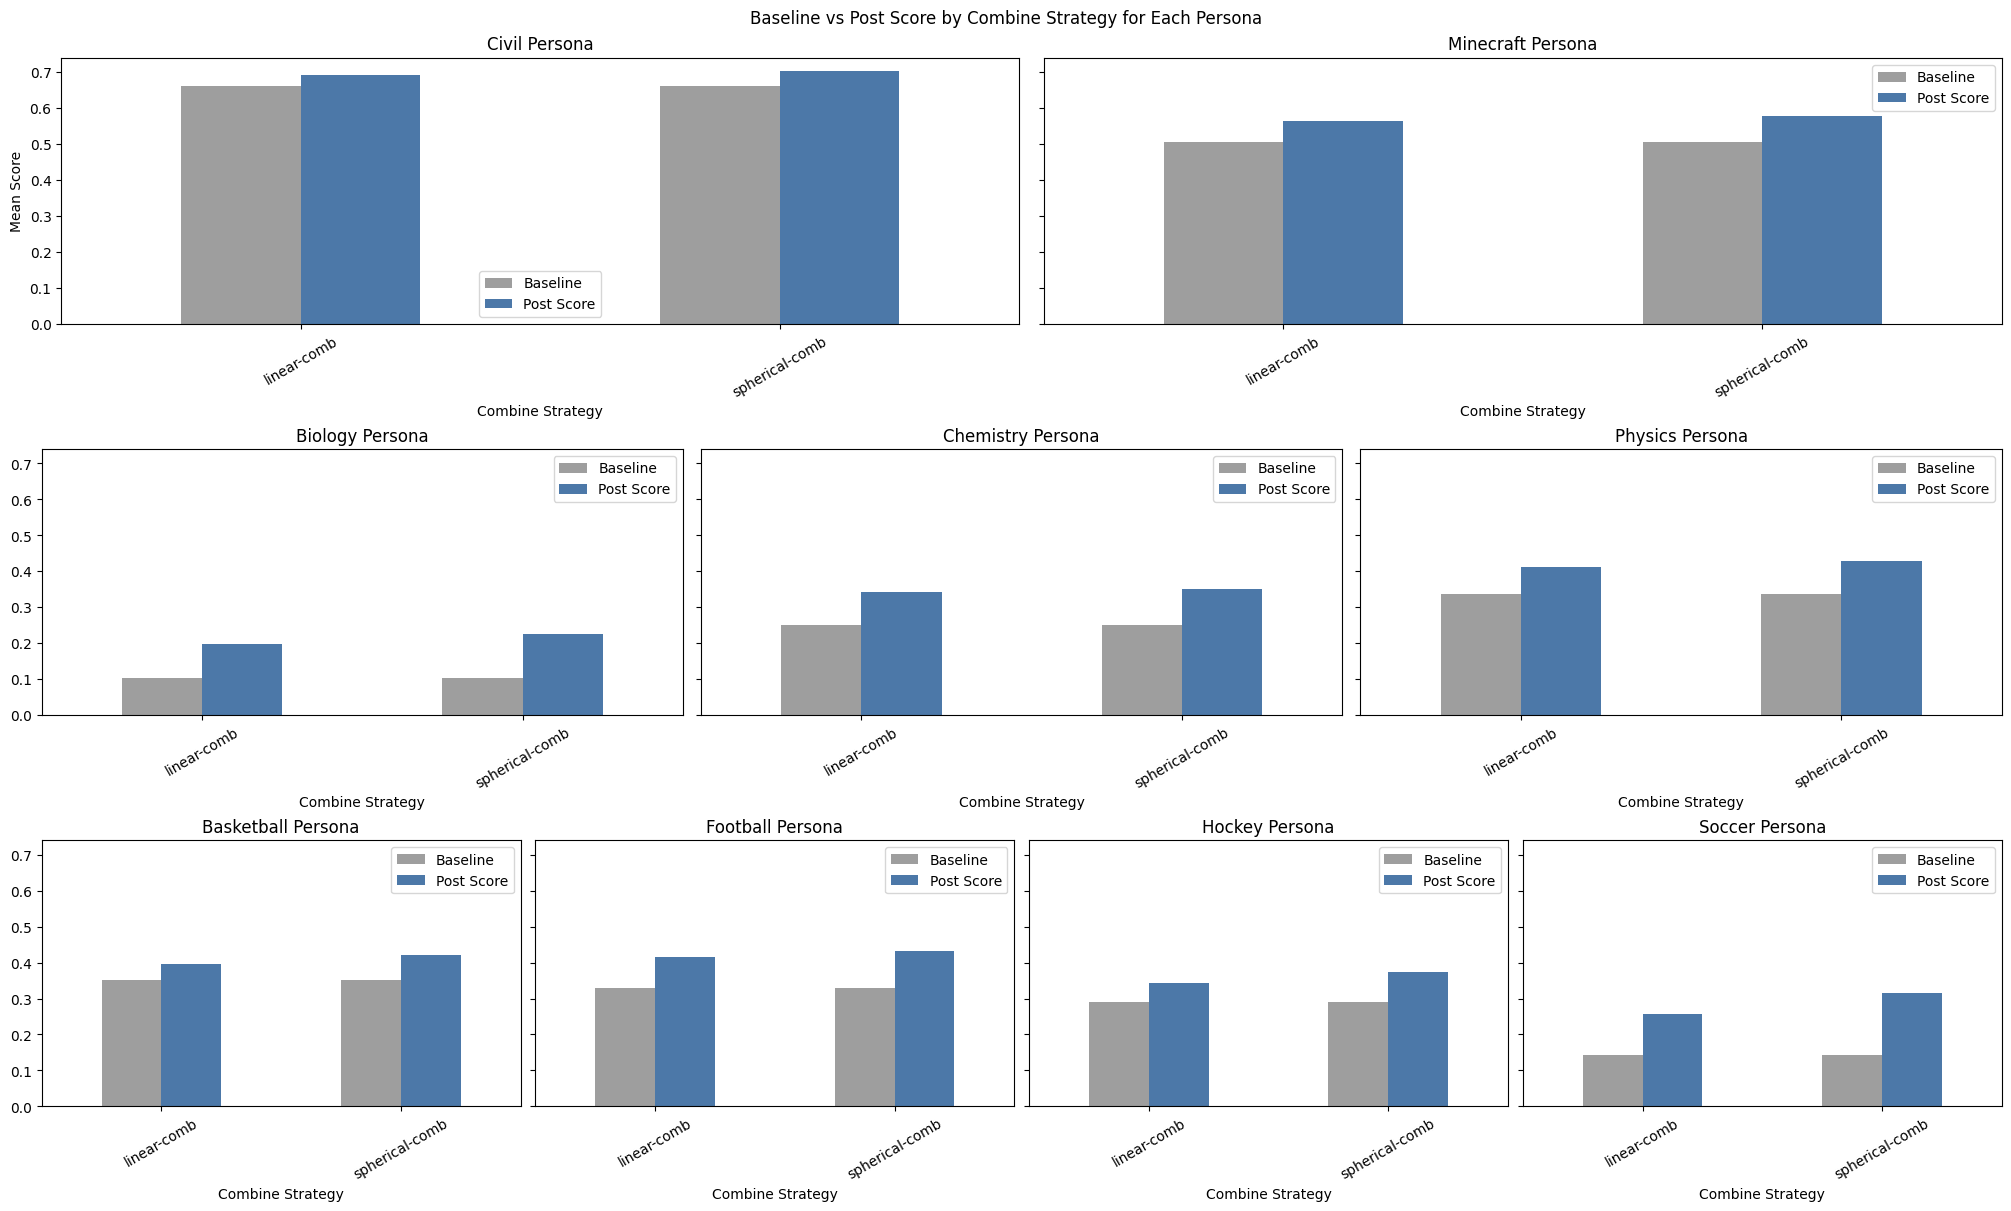

In [ ]:
import matplotlib.pyplot as plt

allowed_combine_strategies = ["linear-comb", "spherical-comb"]
persona_rows = [
    ["civil", "minecraft"],
    ["biology", "chemistry", "physics"],
    ["basketball", "football", "hockey", "soccer"],
]
plot_df = df[df["combine_strategy"].isin(allowed_combine_strategies)]

fig = plt.figure(figsize=(20, 12), constrained_layout=True)
outer = fig.add_gridspec(len(persona_rows), 1)
first_ax = None

for row_idx, row_personas in enumerate(persona_rows):
    inner = outer[row_idx].subgridspec(1, len(row_personas))
    for col_idx, persona in enumerate(row_personas):
        ax = fig.add_subplot(inner[0, col_idx], sharey=first_ax)
        if first_ax is None:
            first_ax = ax

        combine_delta = (
            plot_df[plot_df["persona"].eq(persona)]
            .groupby("combine_strategy", as_index=False)["mean_delta"]
            .mean()
        )
        combine_delta["combine_strategy"] = pd.Categorical(
            combine_delta["combine_strategy"],
            categories=allowed_combine_strategies,
            ordered=True,
        )
        combine_delta = combine_delta.sort_values("combine_strategy")

        combine_delta.plot(
            kind="bar",
            x="combine_strategy",
            y="mean_delta",
            legend=False,
            ax=ax,
            color="#4C78A8",
        )
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(f"{persona.title()} Persona")
        ax.set_xlabel("Combine Strategy")
        ax.tick_params(axis="x", rotation=30)

first_ax.set_ylabel("Mean Delta")
fig.suptitle("Mean Delta by Combine Strategy for Each Persona")
plt.show()

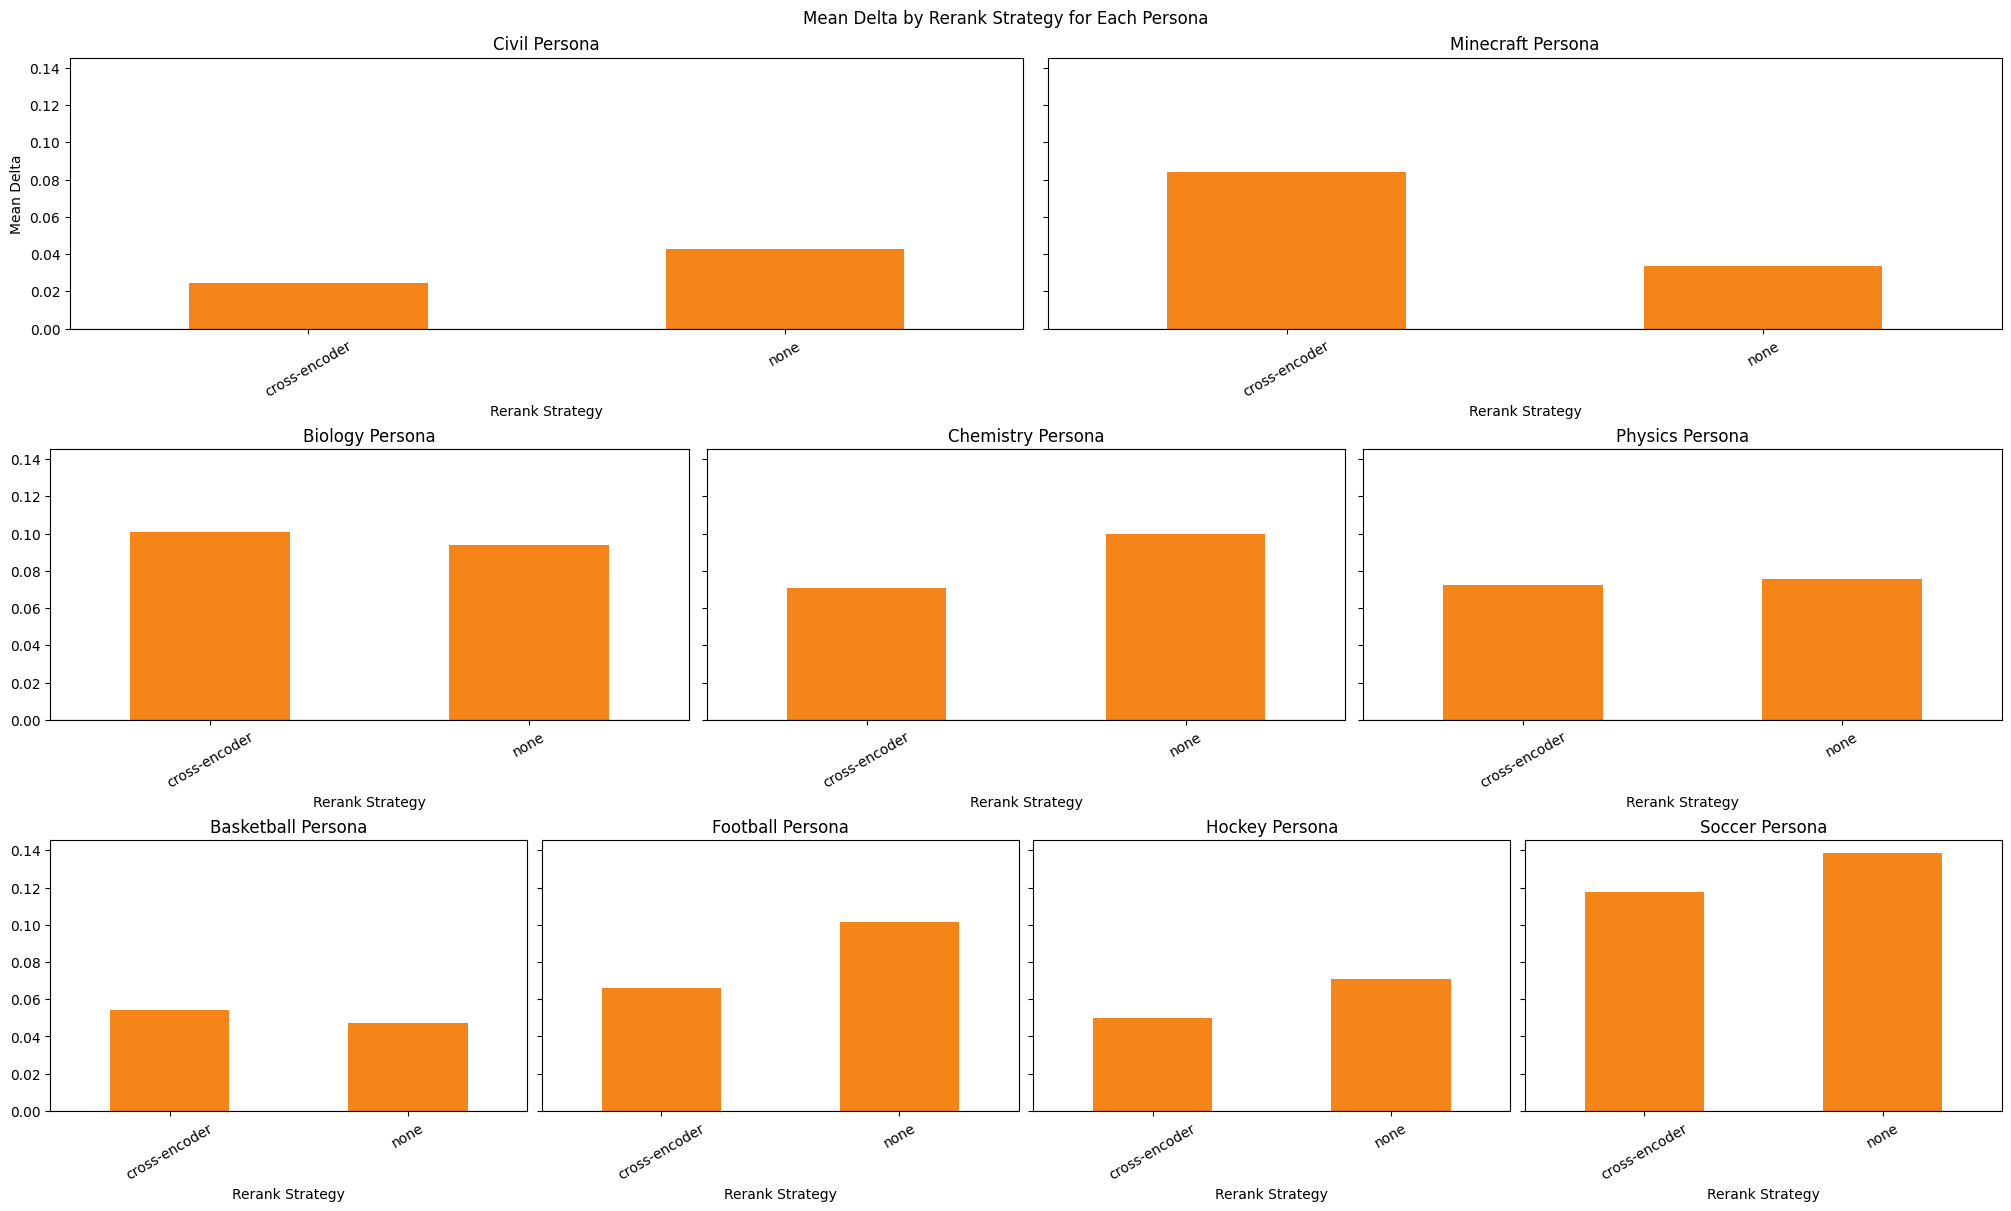

In [ ]:
import matplotlib.pyplot as plt

allowed_rerank_strategies = ["cross-encoder", "none"]
persona_rows = [
    ["civil", "minecraft"],
    ["biology", "chemistry", "physics"],
    ["basketball", "football", "hockey", "soccer"],
]
plot_df = df[df["rerank_strategy"].isin(allowed_rerank_strategies)]

fig = plt.figure(figsize=(20, 12), constrained_layout=True)
outer = fig.add_gridspec(len(persona_rows), 1)
first_ax = None

for row_idx, row_personas in enumerate(persona_rows):
    inner = outer[row_idx].subgridspec(1, len(row_personas))
    for col_idx, persona in enumerate(row_personas):
        ax = fig.add_subplot(inner[0, col_idx], sharey=first_ax)
        if first_ax is None:
            first_ax = ax

        rerank_delta = (
            plot_df[plot_df["persona"].eq(persona)]
            .groupby("rerank_strategy", as_index=False)["mean_delta"]
            .mean()
        )
        rerank_delta["rerank_strategy"] = pd.Categorical(
            rerank_delta["rerank_strategy"],
            categories=allowed_rerank_strategies,
            ordered=True,
        )
        rerank_delta = rerank_delta.sort_values("rerank_strategy")

        rerank_delta.plot(
            kind="bar",
            x="rerank_strategy",
            y="mean_delta",
            legend=False,
            ax=ax,
            color="#F58518",
        )
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(f"{persona.title()} Persona")
        ax.set_xlabel("Rerank Strategy")
        ax.tick_params(axis="x", rotation=30)

first_ax.set_ylabel("Mean Delta")
fig.suptitle("Mean Delta by Rerank Strategy for Each Persona")
plt.show()

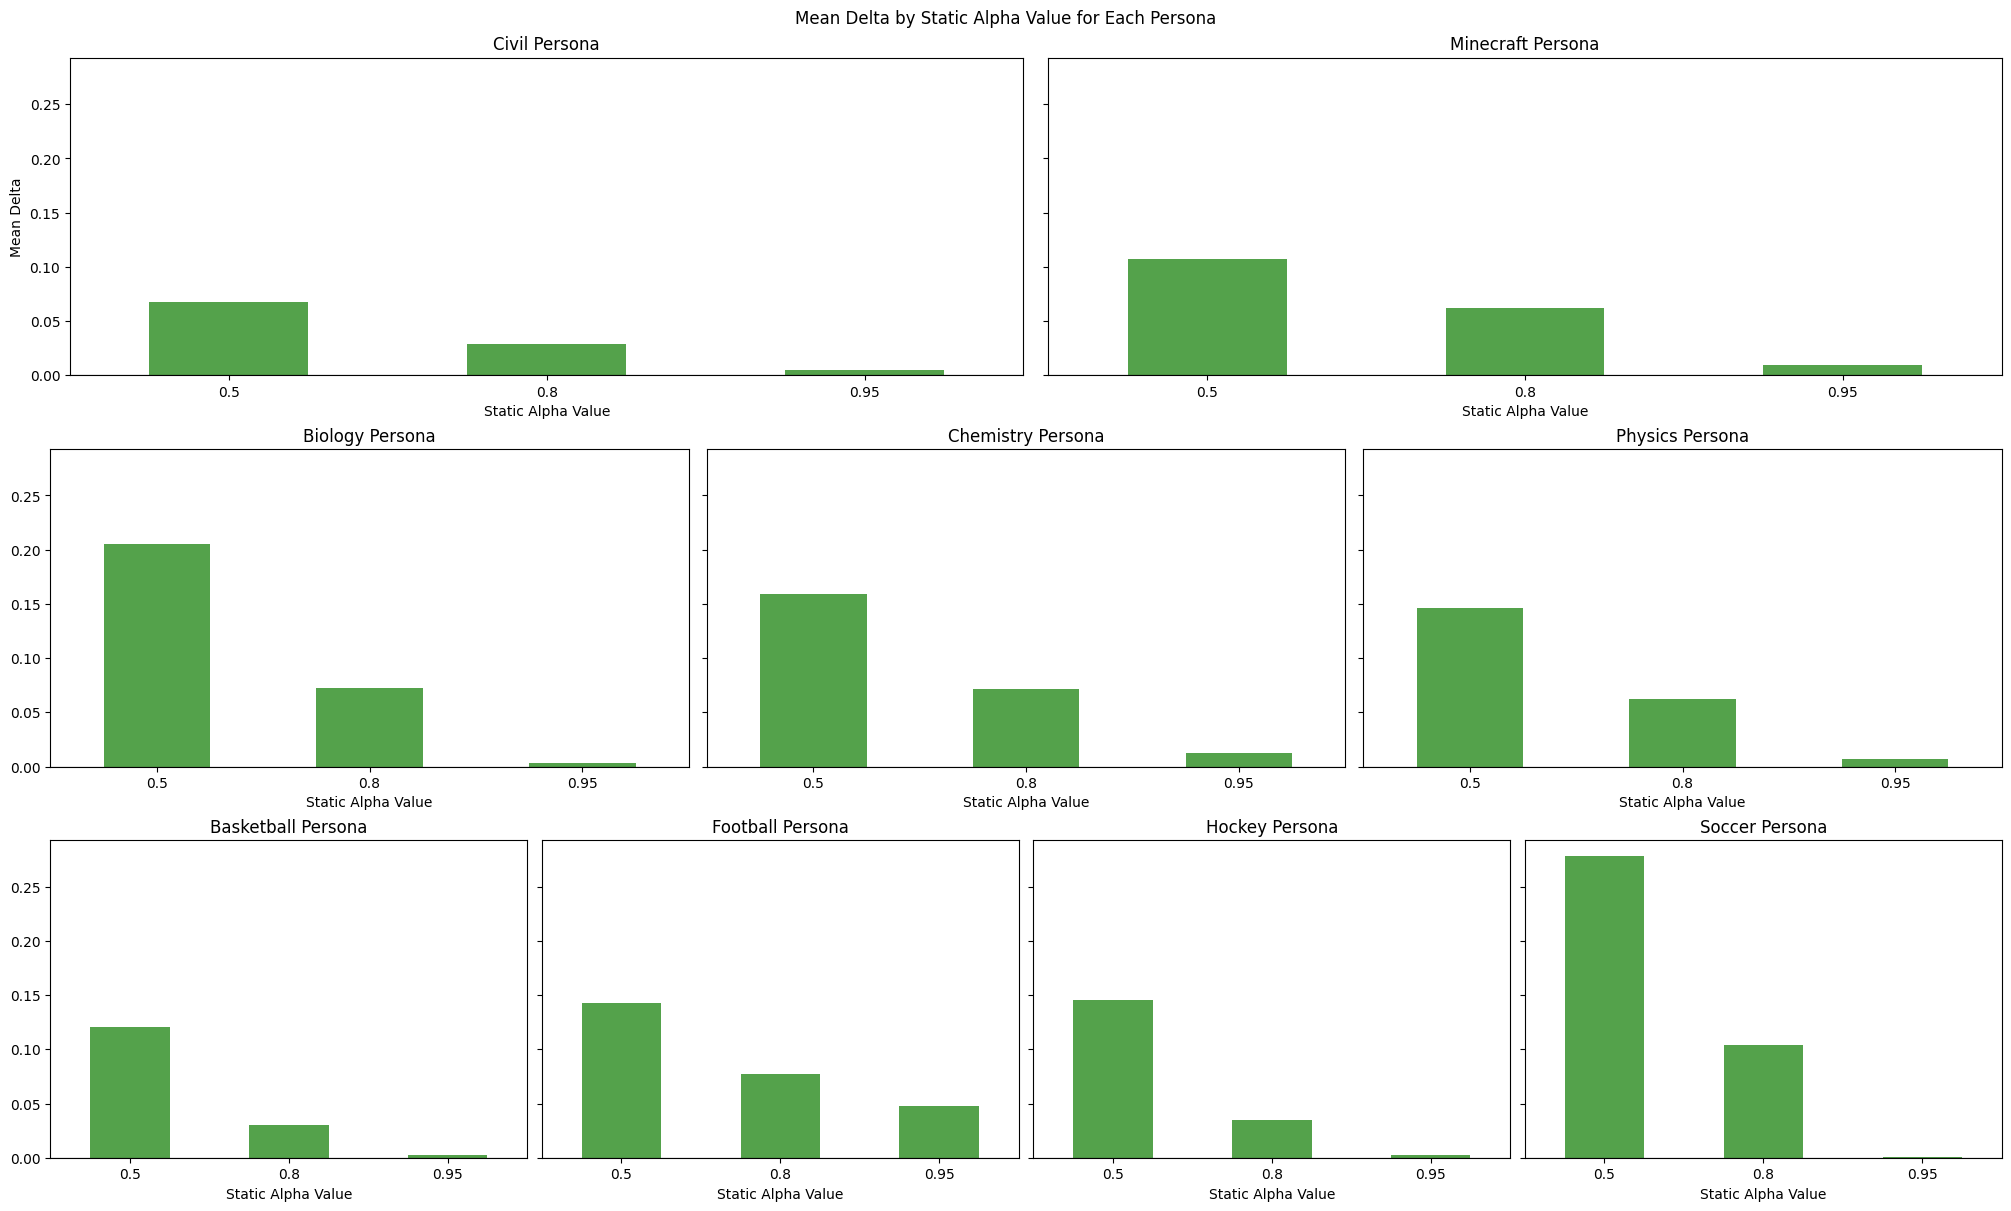

In [ ]:
import matplotlib.pyplot as plt

static_alpha_values = [0.5, 0.8, 0.95]
persona_rows = [
    ["civil", "minecraft"],
    ["biology", "chemistry", "physics"],
    ["basketball", "football", "hockey", "soccer"],
]
plot_df = df[
    df["alpha_mode"].eq("static")
    & df["alpha_value"].round(2).isin(static_alpha_values)
].copy()
plot_df["alpha_label"] = plot_df["alpha_value"].map(lambda value: f"{value:g}")
alpha_labels = [f"{value:g}" for value in static_alpha_values]

fig = plt.figure(figsize=(20, 12), constrained_layout=True)
outer = fig.add_gridspec(len(persona_rows), 1)
first_ax = None

for row_idx, row_personas in enumerate(persona_rows):
    inner = outer[row_idx].subgridspec(1, len(row_personas))
    for col_idx, persona in enumerate(row_personas):
        ax = fig.add_subplot(inner[0, col_idx], sharey=first_ax)
        if first_ax is None:
            first_ax = ax

        alpha_delta = (
            plot_df[plot_df["persona"].eq(persona)]
            .groupby("alpha_label", as_index=False)["mean_delta"]
            .mean()
        )
        alpha_delta["alpha_label"] = pd.Categorical(
            alpha_delta["alpha_label"],
            categories=alpha_labels,
            ordered=True,
        )
        alpha_delta = alpha_delta.sort_values("alpha_label")

        alpha_delta.plot(
            kind="bar",
            x="alpha_label",
            y="mean_delta",
            legend=False,
            ax=ax,
            color="#54A24B",
        )
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(f"{persona.title()} Persona")
        ax.set_xlabel("Static Alpha Value")
        ax.tick_params(axis="x", rotation=0)

first_ax.set_ylabel("Mean Delta")
fig.suptitle("Mean Delta by Static Alpha Value for Each Persona")
plt.show()

In [10]:
alpha_cols = ["alpha_start", "alpha_step", "alpha_floor", "final_alpha"]

df[df["alpha_mode"].eq("sliding")][alpha_cols].drop_duplicates().sort_values(alpha_cols)

,alpha_start,alpha_step,alpha_floor,final_alpha
72,0.99,0.02,0.7,0.70
0,0.99,0.02,0.7,0.79
4,0.99,0.02,0.7,0.99
20,0.99,0.05,0.5,0.50
24,0.99,0.05,0.5,0.99


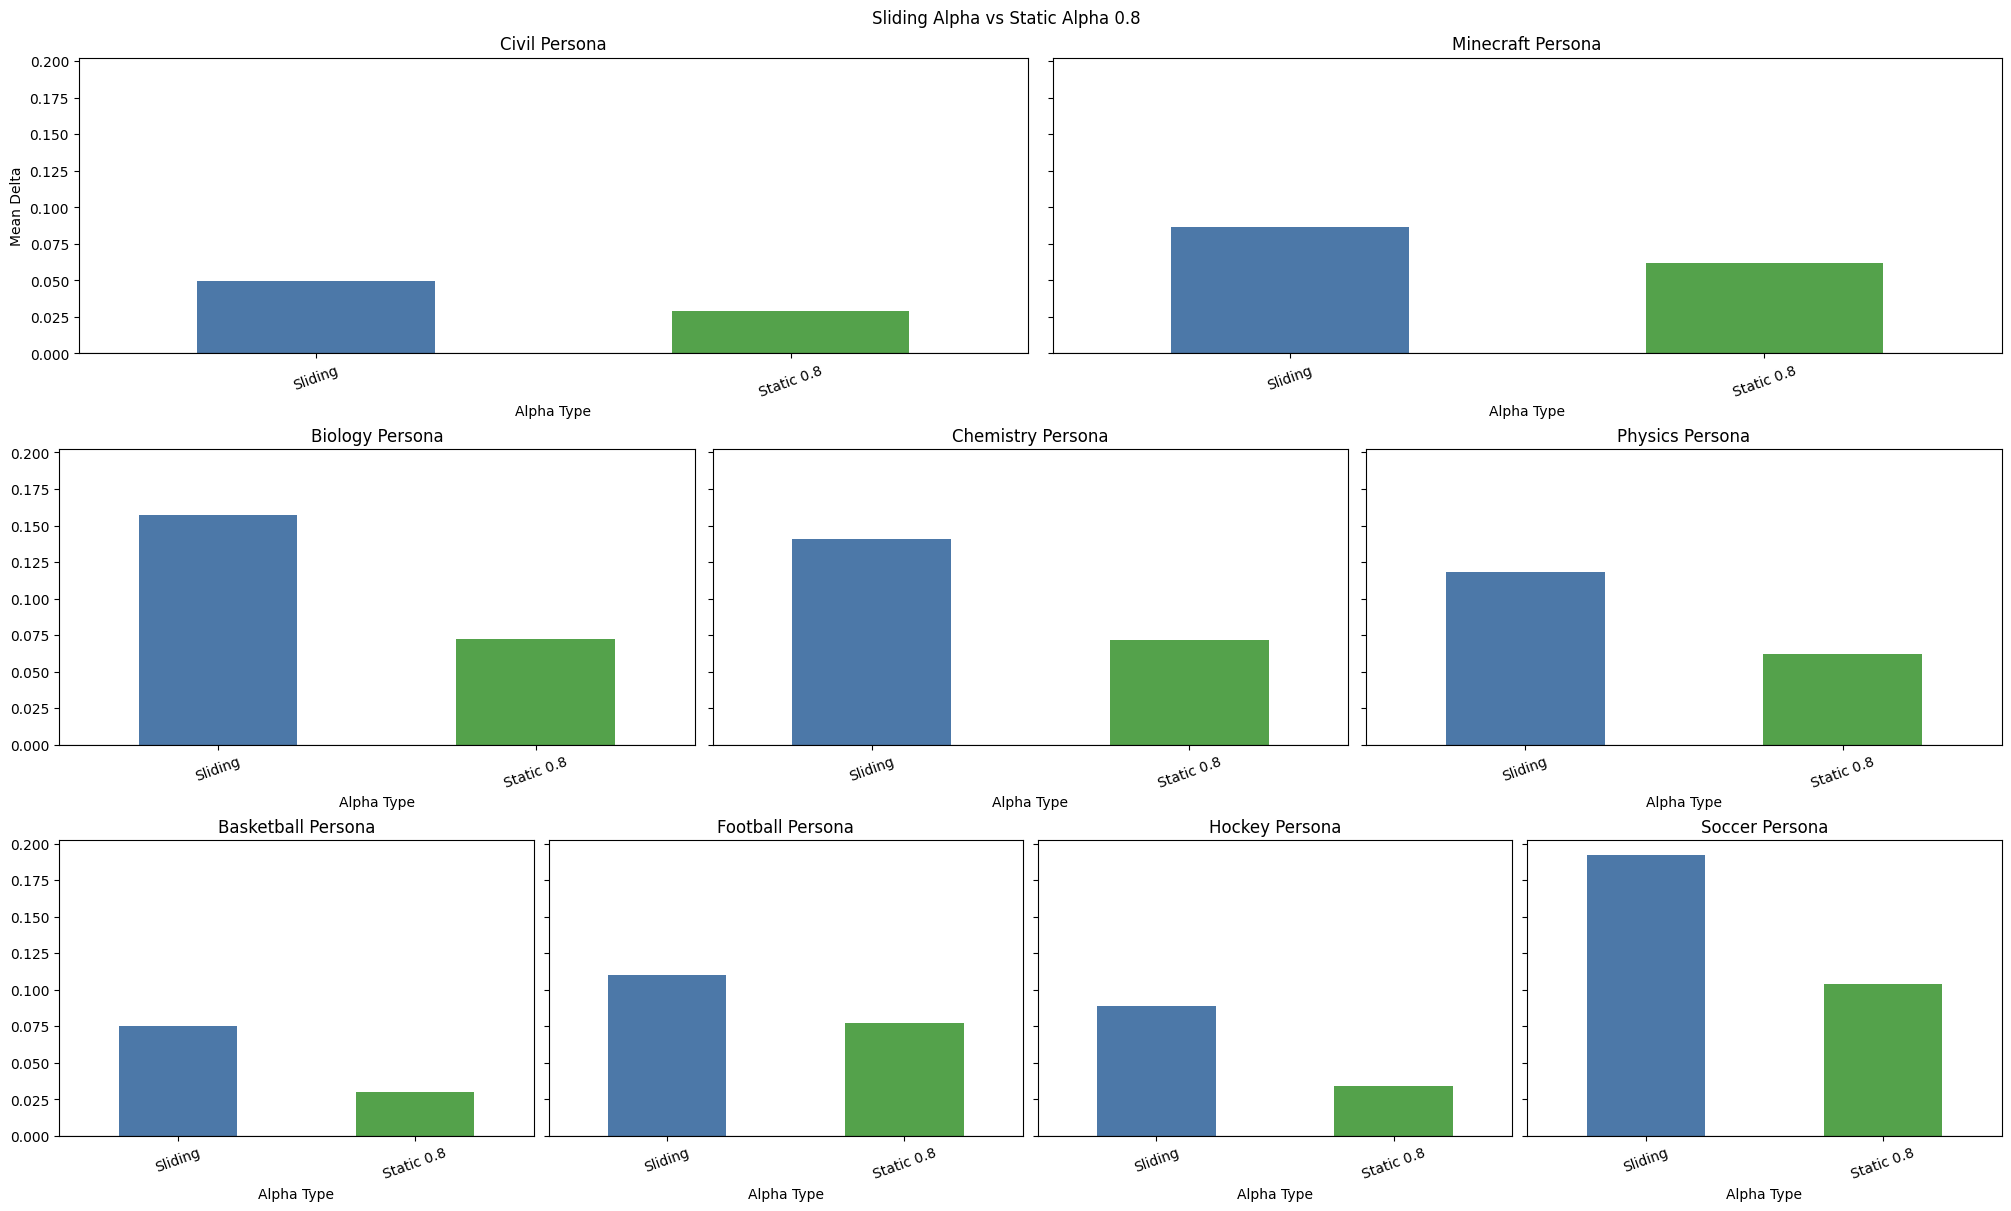

In [ ]:
import matplotlib.pyplot as plt

alpha_type_order = ["Sliding", "Static 0.8"]
persona_rows = [
    ["civil", "minecraft"],
    ["biology", "chemistry", "physics"],
    ["basketball", "football", "hockey", "soccer"],
]
plot_df = df[
    df["alpha_mode"].eq("sliding")
    | (df["alpha_mode"].eq("static") & df["alpha_value"].round(2).eq(0.8))
].copy()
plot_df["alpha_type"] = "Sliding"
plot_df.loc[plot_df["alpha_mode"].eq("static"), "alpha_type"] = "Static 0.8"

fig = plt.figure(figsize=(20, 12), constrained_layout=True)
outer = fig.add_gridspec(len(persona_rows), 1)
first_ax = None

for row_idx, row_personas in enumerate(persona_rows):
    inner = outer[row_idx].subgridspec(1, len(row_personas))
    for col_idx, persona in enumerate(row_personas):
        ax = fig.add_subplot(inner[0, col_idx], sharey=first_ax)
        if first_ax is None:
            first_ax = ax

        alpha_delta = (
            plot_df[plot_df["persona"].eq(persona)]
            .groupby("alpha_type", as_index=False)["mean_delta"]
            .mean()
        )
        alpha_delta["alpha_type"] = pd.Categorical(
            alpha_delta["alpha_type"],
            categories=alpha_type_order,
            ordered=True,
        )
        alpha_delta = alpha_delta.sort_values("alpha_type")

        alpha_delta.plot(
            kind="bar",
            x="alpha_type",
            y="mean_delta",
            legend=False,
            ax=ax,
            color=["#4C78A8", "#54A24B"],
        )
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(f"{persona.title()} Persona")
        ax.set_xlabel("Alpha Type")
        ax.tick_params(axis="x", rotation=20)

first_ax.set_ylabel("Mean Delta")
fig.suptitle("Sliding Alpha vs Static Alpha 0.8")
plt.show()

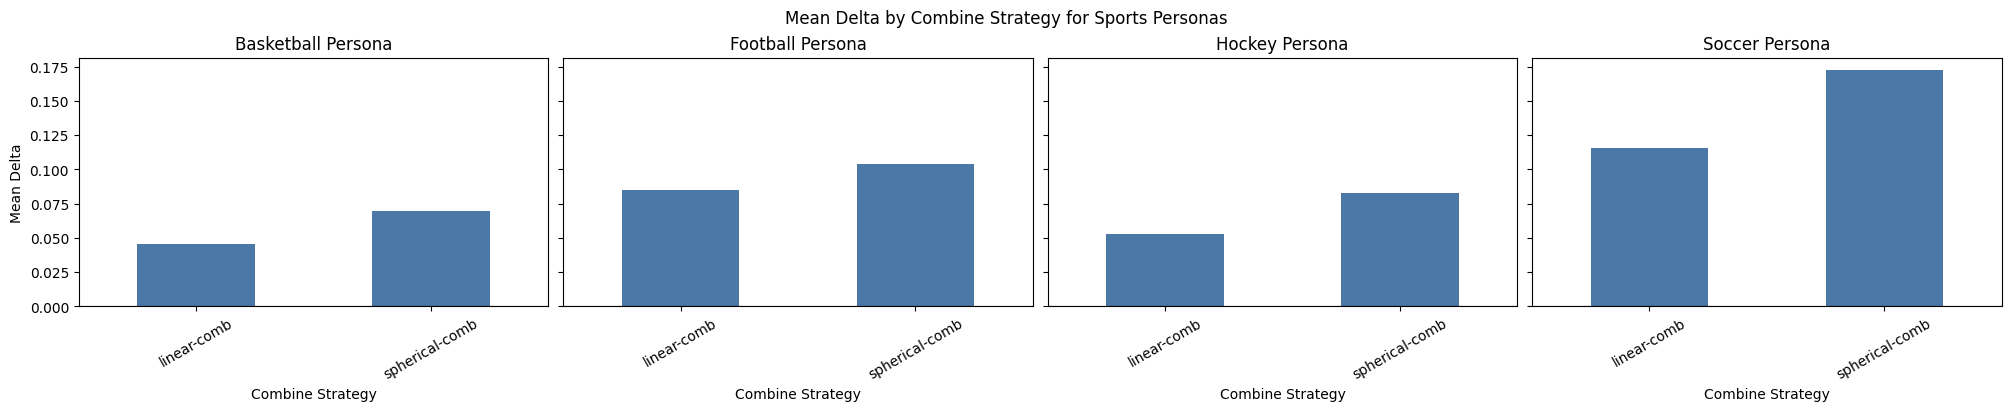

In [ ]:
import matplotlib.pyplot as plt

allowed_combine_strategies = ["linear-comb", "spherical-comb"]
sports_personas = ["basketball", "football", "hockey", "soccer"]
plot_df = df[df["combine_strategy"].isin(allowed_combine_strategies)]

fig = plt.figure(figsize=(20, 4), constrained_layout=True)
outer = fig.add_gridspec(1, len(sports_personas))
first_ax = None

for col_idx, persona in enumerate(sports_personas):
    ax = fig.add_subplot(outer[0, col_idx], sharey=first_ax)
    if first_ax is None:
        first_ax = ax

    combine_delta = (
        plot_df[plot_df["persona"].eq(persona)]
        .groupby("combine_strategy", as_index=False)["mean_delta"]
        .mean()
    )
    combine_delta["combine_strategy"] = pd.Categorical(
        combine_delta["combine_strategy"],
        categories=allowed_combine_strategies,
        ordered=True,
    )
    combine_delta = combine_delta.sort_values("combine_strategy")

    combine_delta.plot(
        kind="bar",
        x="combine_strategy",
        y="mean_delta",
        legend=False,
        ax=ax,
        color="#4C78A8",
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{persona.title()} Persona")
    ax.set_xlabel("Combine Strategy")
    ax.tick_params(axis="x", rotation=30)

first_ax.set_ylabel("Mean Delta")
fig.suptitle("Mean Delta by Combine Strategy for Sports Personas")
plt.show()

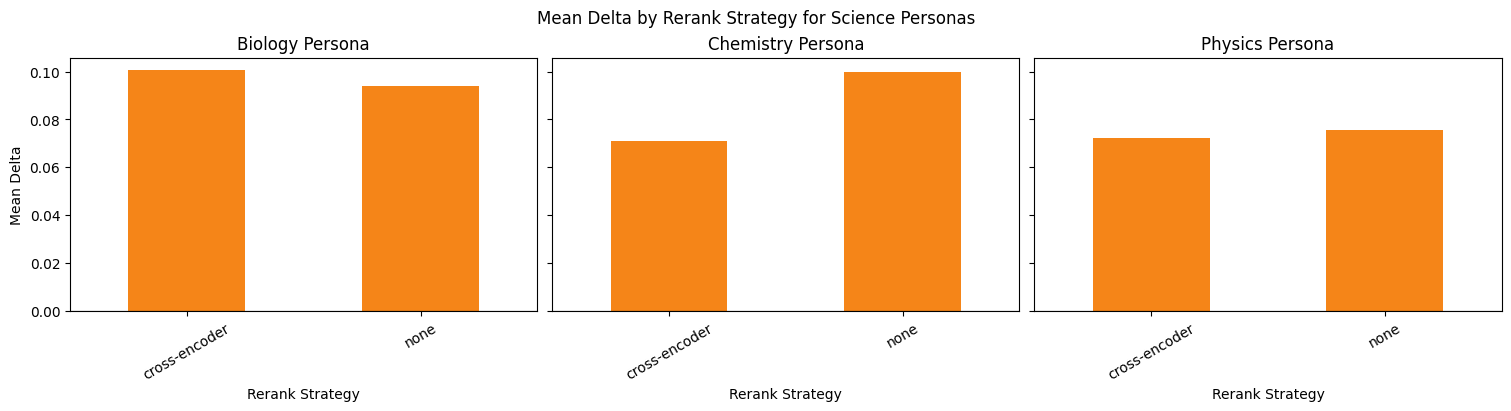

In [ ]:
import matplotlib.pyplot as plt

allowed_rerank_strategies = ["cross-encoder", "none"]
science_personas = ["biology", "chemistry", "physics"]
plot_df = df[df["rerank_strategy"].isin(allowed_rerank_strategies)]

fig = plt.figure(figsize=(15, 4), constrained_layout=True)
outer = fig.add_gridspec(1, len(science_personas))
first_ax = None

for col_idx, persona in enumerate(science_personas):
    ax = fig.add_subplot(outer[0, col_idx], sharey=first_ax)
    if first_ax is None:
        first_ax = ax

    rerank_delta = (
        plot_df[plot_df["persona"].eq(persona)]
        .groupby("rerank_strategy", as_index=False)["mean_delta"]
        .mean()
    )
    rerank_delta["rerank_strategy"] = pd.Categorical(
        rerank_delta["rerank_strategy"],
        categories=allowed_rerank_strategies,
        ordered=True,
    )
    rerank_delta = rerank_delta.sort_values("rerank_strategy")

    rerank_delta.plot(
        kind="bar",
        x="rerank_strategy",
        y="mean_delta",
        legend=False,
        ax=ax,
        color="#F58518",
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{persona.title()} Persona")
    ax.set_xlabel("Rerank Strategy")
    ax.tick_params(axis="x", rotation=30)

first_ax.set_ylabel("Mean Delta")
fig.suptitle("Mean Delta by Rerank Strategy for Science Personas")
plt.show()

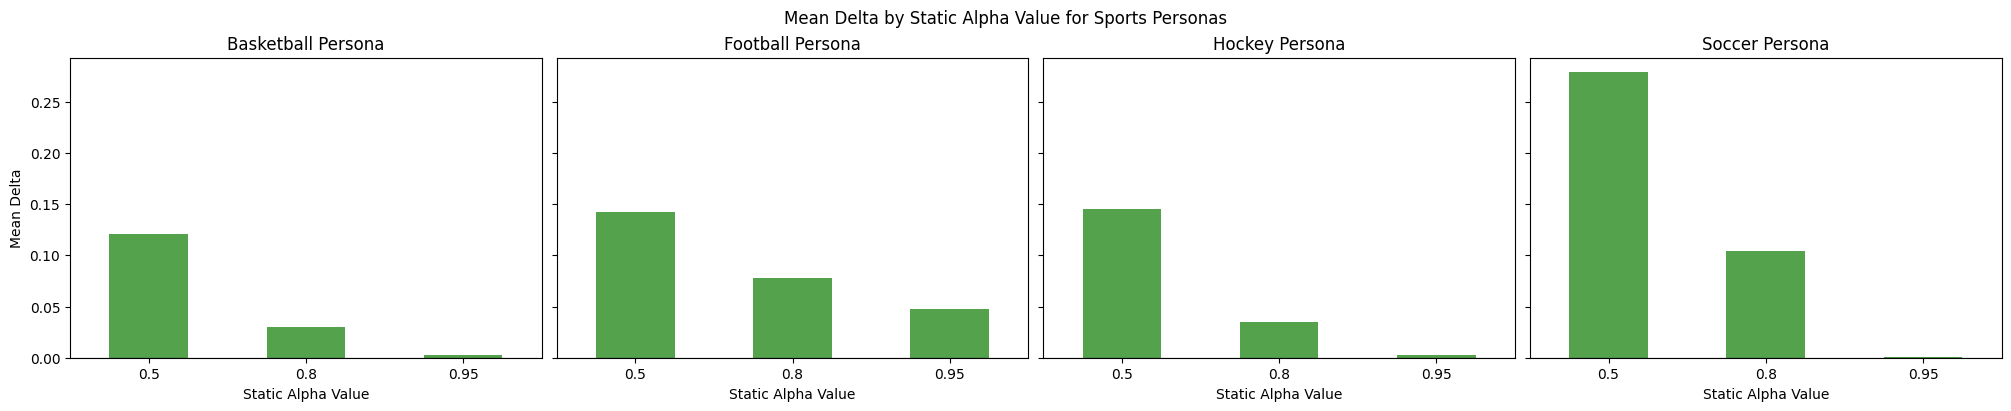

In [ ]:
import matplotlib.pyplot as plt

static_alpha_values = [0.5, 0.8, 0.95]
sports_personas = ["basketball", "football", "hockey", "soccer"]
plot_df = df[
    df["alpha_mode"].eq("static")
    & df["alpha_value"].round(2).isin(static_alpha_values)
].copy()
plot_df["alpha_label"] = plot_df["alpha_value"].map(lambda value: f"{value:g}")
alpha_labels = [f"{value:g}" for value in static_alpha_values]

fig = plt.figure(figsize=(20, 4), constrained_layout=True)
outer = fig.add_gridspec(1, len(sports_personas))
first_ax = None

for col_idx, persona in enumerate(sports_personas):
    ax = fig.add_subplot(outer[0, col_idx], sharey=first_ax)
    if first_ax is None:
        first_ax = ax

    alpha_delta = (
        plot_df[plot_df["persona"].eq(persona)]
        .groupby("alpha_label", as_index=False)["mean_delta"]
        .mean()
    )
    alpha_delta["alpha_label"] = pd.Categorical(
        alpha_delta["alpha_label"],
        categories=alpha_labels,
        ordered=True,
    )
    alpha_delta = alpha_delta.sort_values("alpha_label")

    alpha_delta.plot(
        kind="bar",
        x="alpha_label",
        y="mean_delta",
        legend=False,
        ax=ax,
        color="#54A24B",
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{persona.title()} Persona")
    ax.set_xlabel("Static Alpha Value")
    ax.tick_params(axis="x", rotation=0)

first_ax.set_ylabel("Mean Delta")
fig.suptitle("Mean Delta by Static Alpha Value for Sports Personas")
plt.show()

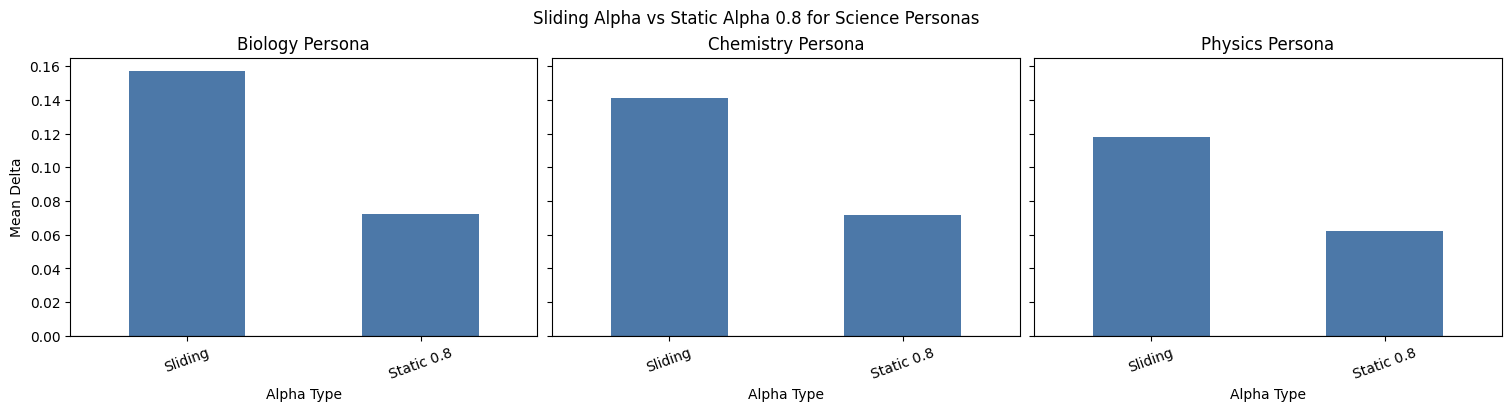

In [ ]:
import matplotlib.pyplot as plt

alpha_type_order = ["Sliding", "Static 0.8"]
science_personas = ["biology", "chemistry", "physics"]
plot_df = df[
    df["alpha_mode"].eq("sliding")
    | (df["alpha_mode"].eq("static") & df["alpha_value"].round(2).eq(0.8))
].copy()
plot_df["alpha_type"] = "Sliding"
plot_df.loc[plot_df["alpha_mode"].eq("static"), "alpha_type"] = "Static 0.8"

fig = plt.figure(figsize=(15, 4), constrained_layout=True)
outer = fig.add_gridspec(1, len(science_personas))
first_ax = None

for col_idx, persona in enumerate(science_personas):
    ax = fig.add_subplot(outer[0, col_idx], sharey=first_ax)
    if first_ax is None:
        first_ax = ax

    alpha_delta = (
        plot_df[plot_df["persona"].eq(persona)]
        .groupby("alpha_type", as_index=False)["mean_delta"]
        .mean()
    )
    alpha_delta["alpha_type"] = pd.Categorical(
        alpha_delta["alpha_type"],
        categories=alpha_type_order,
        ordered=True,
    )
    alpha_delta = alpha_delta.sort_values("alpha_type")

    alpha_delta.plot(
        kind="bar",
        x="alpha_type",
        y="mean_delta",
        legend=False,
        ax=ax,
        color="#4C78A8",
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{persona.title()} Persona")
    ax.set_xlabel("Alpha Type")
    ax.tick_params(axis="x", rotation=20)

first_ax.set_ylabel("Mean Delta")
fig.suptitle("Sliding Alpha vs Static Alpha 0.8 for Science Personas")
plt.show()

In [ ]:
allowed_combine_strategies = ["linear-comb", "spherical-comb"]
persona_order = [
    "civil",
    "minecraft",
    "biology",
    "chemistry",
    "physics",
    "basketball",
    "football",
    "hockey",
    "soccer",
]

combine_table = (
    df[df["combine_strategy"].isin(allowed_combine_strategies)]
    .groupby(["persona", "combine_strategy"], as_index=False)["mean_delta"]
    .mean()
)
combine_table["persona"] = pd.Categorical(
    combine_table["persona"],
    categories=persona_order,
    ordered=True,
)
combine_table["combine_strategy"] = pd.Categorical(
    combine_table["combine_strategy"],
    categories=allowed_combine_strategies,
    ordered=True,
)

combine_table = (
    combine_table
    .pivot(index="persona", columns="combine_strategy", values="mean_delta")
    .sort_index()
)
combine_table

combine_strategy,linear-comb,spherical-comb
persona,,
civil,0.031720,0.043723
minecraft,0.059310,0.073013
biology,0.095180,0.123508
chemistry,0.091896,0.100093
physics,0.075244,0.091247
basketball,0.045189,0.069245
football,0.084666,0.104010
hockey,0.052916,0.082614
soccer,0.115348,0.172598


In [ ]:
latex_table = (
    combine_table
    .rename(columns={
        "linear-comb": "Linear Combination",
        "spherical-comb": "Spherical Combination",
    })
    .to_latex(
        float_format="%.3f",
        caption="Mean Delta by Combine Strategy for Each Persona",
        label="tab:combine-strategy-delta",
    )
)

print(latex_table)

\begin{table}
\caption{Mean Delta by Combine Strategy for Each Persona}
\label{tab:combine-strategy-delta}
\begin{tabular}{lrr}
\toprule
combine_strategy & Linear Combination & Spherical Combination \\
persona &  &  \\
\midrule
civil & 0.032 & 0.044 \\
minecraft & 0.059 & 0.073 \\
biology & 0.095 & 0.124 \\
chemistry & 0.092 & 0.100 \\
physics & 0.075 & 0.091 \\
basketball & 0.045 & 0.069 \\
football & 0.085 & 0.104 \\
hockey & 0.053 & 0.083 \\
soccer & 0.115 & 0.173 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
allowed_rerank_strategies = ["cross-encoder", "none"]
persona_order = [
    "civil",
    "minecraft",
    "biology",
    "chemistry",
    "physics",
    "basketball",
    "football",
    "hockey",
    "soccer",
]

rerank_table = (
    df[df["rerank_strategy"].isin(allowed_rerank_strategies)]
    .groupby(["persona", "rerank_strategy"], as_index=False)["mean_delta"]
    .mean()
)
rerank_table["persona"] = pd.Categorical(
    rerank_table["persona"],
    categories=persona_order,
    ordered=True,
)
rerank_table["rerank_strategy"] = pd.Categorical(
    rerank_table["rerank_strategy"],
    categories=allowed_rerank_strategies,
    ordered=True,
)

rerank_table = (
    rerank_table
    .pivot(index="persona", columns="rerank_strategy", values="mean_delta")
    .sort_index()
)

latex_table = (
    rerank_table
    .rename(columns={
        "cross-encoder": "Cross Encoder",
        "none": "No Rerank",
    })
    .to_latex(
        float_format="%.3f",
        caption="Mean Delta by Rerank Strategy for Each Persona",
        label="tab:rerank-strategy-delta",
    )
)

print(latex_table)
rerank_table

\begin{table}
\caption{Mean Delta by Rerank Strategy for Each Persona}
\label{tab:rerank-strategy-delta}
\begin{tabular}{lrr}
\toprule
rerank_strategy & Cross Encoder & No Rerank \\
persona &  &  \\
\midrule
civil & 0.024 & 0.043 \\
minecraft & 0.084 & 0.034 \\
biology & 0.101 & 0.094 \\
chemistry & 0.071 & 0.100 \\
physics & 0.072 & 0.076 \\
basketball & 0.054 & 0.047 \\
football & 0.066 & 0.102 \\
hockey & 0.050 & 0.071 \\
soccer & 0.118 & 0.138 \\
\bottomrule
\end{tabular}
\end{table}



rerank_strategy,cross-encoder,none
persona,,
civil,0.024390,0.042671
minecraft,0.083822,0.033798
biology,0.100619,0.093771
chemistry,0.070912,0.099745
physics,0.072366,0.075626
basketball,0.054487,0.047232
football,0.066174,0.101538
hockey,0.049669,0.070802
soccer,0.117579,0.138373


In [ ]:
static_alpha_values = [0.5, 0.8, 0.95]
persona_order = [
    "civil",
    "minecraft",
    "biology",
    "chemistry",
    "physics",
    "basketball",
    "football",
    "hockey",
    "soccer",
]
alpha_labels = [f"{value:g}" for value in static_alpha_values]

static_alpha_table = df[
    df["alpha_mode"].eq("static")
    & df["alpha_value"].round(2).isin(static_alpha_values)
].copy()
static_alpha_table["alpha_label"] = static_alpha_table["alpha_value"].map(lambda value: f"{value:g}")
static_alpha_table = (
    static_alpha_table
    .groupby(["persona", "alpha_label"], as_index=False)["mean_delta"]
    .mean()
)
static_alpha_table["persona"] = pd.Categorical(
    static_alpha_table["persona"],
    categories=persona_order,
    ordered=True,
)
static_alpha_table["alpha_label"] = pd.Categorical(
    static_alpha_table["alpha_label"],
    categories=alpha_labels,
    ordered=True,
)

static_alpha_table = (
    static_alpha_table
    .pivot(index="persona", columns="alpha_label", values="mean_delta")
    .sort_index()
)

latex_table = static_alpha_table.to_latex(
    float_format="%.3f",
    caption="Mean Delta by Static Alpha Value for Each Persona",
    label="tab:static-alpha-delta",
)

print(latex_table)
static_alpha_table

\begin{table}
\caption{Mean Delta by Static Alpha Value for Each Persona}
\label{tab:static-alpha-delta}
\begin{tabular}{lrrr}
\toprule
alpha_label & 0.5 & 0.8 & 0.95 \\
persona &  &  &  \\
\midrule
civil & 0.067 & 0.029 & 0.005 \\
minecraft & 0.107 & 0.062 & 0.009 \\
biology & 0.205 & 0.072 & 0.003 \\
chemistry & 0.159 & 0.072 & 0.012 \\
physics & 0.146 & 0.062 & 0.007 \\
basketball & 0.121 & 0.030 & 0.003 \\
football & 0.142 & 0.078 & 0.048 \\
hockey & 0.146 & 0.034 & 0.002 \\
soccer & 0.279 & 0.104 & 0.001 \\
\bottomrule
\end{tabular}
\end{table}



alpha_label,0.5,0.8,0.95
persona,,,
civil,0.067267,0.028828,0.005197
minecraft,0.106950,0.061811,0.009417
biology,0.204978,0.072293,0.003103
chemistry,0.159151,0.071601,0.012220
physics,0.146208,0.062300,0.006533
basketball,0.120844,0.029989,0.002703
football,0.142428,0.077558,0.047580
hockey,0.145555,0.034498,0.002221
soccer,0.278673,0.104078,0.000556


In [ ]:
alpha_type_order = ["Sliding", "Static 0.8"]
persona_order = [
    "civil",
    "minecraft",
    "biology",
    "chemistry",
    "physics",
    "basketball",
    "football",
    "hockey",
    "soccer",
]

alpha_type_table = df[
    df["alpha_mode"].eq("sliding")
    | (df["alpha_mode"].eq("static") & df["alpha_value"].round(2).eq(0.8))
].copy()
alpha_type_table["alpha_type"] = "Sliding"
alpha_type_table.loc[alpha_type_table["alpha_mode"].eq("static"), "alpha_type"] = "Static 0.8"
alpha_type_table = (
    alpha_type_table
    .groupby(["persona", "alpha_type"], as_index=False)["mean_delta"]
    .mean()
)
alpha_type_table["persona"] = pd.Categorical(
    alpha_type_table["persona"],
    categories=persona_order,
    ordered=True,
)
alpha_type_table["alpha_type"] = pd.Categorical(
    alpha_type_table["alpha_type"],
    categories=alpha_type_order,
    ordered=True,
)

alpha_type_table = (
    alpha_type_table
    .pivot(index="persona", columns="alpha_type", values="mean_delta")
    .sort_index()
)

latex_table = alpha_type_table.to_latex(
    float_format="%.3f",
    caption="Mean Delta for Sliding Alpha vs Static Alpha 0.8 by Persona",
    label="tab:sliding-vs-static-alpha-delta",
)

print(latex_table)
alpha_type_table

\begin{table}
\caption{Mean Delta for Sliding Alpha vs Static Alpha 0.8 by Persona}
\label{tab:sliding-vs-static-alpha-delta}
\begin{tabular}{lrr}
\toprule
alpha_type & Sliding & Static 0.8 \\
persona &  &  \\
\midrule
civil & 0.050 & 0.029 \\
minecraft & 0.086 & 0.062 \\
biology & 0.157 & 0.072 \\
chemistry & 0.141 & 0.072 \\
physics & 0.118 & 0.062 \\
basketball & 0.075 & 0.030 \\
football & 0.110 & 0.078 \\
hockey & 0.089 & 0.034 \\
soccer & 0.193 & 0.104 \\
\bottomrule
\end{tabular}
\end{table}



alpha_type,Sliding,Static 0.8
persona,,
civil,0.049596,0.028828
minecraft,0.086468,0.061811
biology,0.157003,0.072293
chemistry,0.141005,0.071601
physics,0.117941,0.062300
basketball,0.075331,0.029989
football,0.109786,0.077558
hockey,0.088786,0.034498
soccer,0.192584,0.104078
